In [5]:
# import libraries
import os
import pandas as pd
import glob

# define file paths
NEW_LAB_PATH = './model/data/lab/'
OLD_LAB_PATH = './presumed_infection/2.Data/Lab_Test_Results/'
WARD_PATH = './model/data/ward/'
OUTPUT_PATH = './model/output/'
ASE_DEMO_PATH = './presumed_infection/2.Data/Demographics/2022/demographic_ASE_2022.csv'

In [ ]:
# extract 2022 demographic data
# df = pd.read_csv('./presumed_infection/2.Data/Demographics/demographic_SIC_all.csv')
# df[df['Year'] == 2022].to_csv('./presumed_infection/2.Data/Demographics/2022/demographic_SIC_2022.csv', index=False)

In [ ]:
# save demographic variables
df = pd.read_csv(ASE_DEMO_PATH)
SIC_data = df[['Reference Key', 'HN Number', 'Institution (IPAS)', 'SIC', 'plt_true_date', 'Sex', 'Admission Age (Year) (episode based)']].copy() # sex, age
SIC_data = SIC_data.drop_duplicates(subset='Reference Key') # remove dupes
SIC_data.rename(columns={'Admission Age (Year) (episode based)': 'Age'}, inplace=True)

HTN_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('hypertension', case=False, na=False)]['Reference Key'].unique() # hypertension, included all kinds
SIC_data['HTN'] = SIC_data['Reference Key'].isin(HTN_keys)

CKD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('chronic kidney disease', case=False, na=False)]['Reference Key'].unique() # chronic kidney disease
SIC_data['CKD'] = SIC_data['Reference Key'].isin(CKD_keys)

CA_codes = df[df['Dx/Px code'].astype(str).str.split('.').str[0].str.match(r'^(14[0-9]|1[5-9][0-9]|2[0-3][0-9])')]['Reference Key'].unique() # cancer, dxpx code 140-239
SIC_data['CA'] = SIC_data['Reference Key'].isin(CA_codes)

DM_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('diabetes mellitus', case=False, na=False)]['Reference Key'].unique() # diabetes mellitus, excluded neuropathy
SIC_data['DM'] = SIC_data['Reference Key'].isin(DM_keys)

HLD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('hyperlipidemia', case=False, na=False)]['Reference Key'].unique() # hyperlipidemia
SIC_data['HLD'] = SIC_data['Reference Key'].isin(HLD_keys)

HF_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('heart failure|CHF', case=False, na=False)]['Reference Key'].unique() # heart failure
SIC_data['HF'] = SIC_data['Reference Key'].isin(HF_keys)

IHD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('IHD', case=False, na=False)]['Reference Key'].unique() # ischemic heart disease
SIC_data['IHD'] = SIC_data['Reference Key'].isin(IHD_keys)

COPD_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('COPD', case=False, na=False)]['Reference Key'].unique() # COPD
SIC_data['COPD'] = SIC_data['Reference Key'].isin(COPD_keys)

Vent_keys = df[df['Dx/Px Description (HAMDCT)'].str.contains('ventilation', case=False, na=False)]['Reference Key'].unique() # ventilation
SIC_data['Vent'] = SIC_data['Reference Key'].isin(Vent_keys)

SIC_data.to_csv('./presumed_infection/2.Data/Demographics/SIC_data.csv', index=False)
SIC_data.to_csv('./model/data/SIC_data.csv', index=False)

In [ ]:
# save lab data (first 24 hours)
lab_df = pd.read_csv('./model/data/lab/merged_lab_data.csv')
demo_df = pd.read_csv(ASE_DEMO_PATH)
demo_df['Admission Date (yyyy-mm-dd)'] = pd.to_datetime(demo_df['Admission Date (yyyy-mm-dd)'], errors='coerce')
lab_df['LIS Reference Datetime'] = pd.to_datetime(lab_df['LIS Reference Datetime'], errors='coerce')
SIC_data = pd.read_csv('./model/data/SIC_data.csv')
# SIC_data = SIC_data.head(10)
print(f"Processing {len(SIC_data)} patients for lab data extraction...")

Lym_data = [] # lymphocyte (lowest)
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        lym_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Lymphocyte', case=False, na=False)]['LIS Result: Numeric Result']
        if len(lym_values) > 0:
            lym_min = lym_values.min()
        else:
            lym_min = None
    else:
        lym_min = None
    Lym_data.append(lym_min)
SIC_data['Lym'] = Lym_data
print("  Completed: Lymphocyte")

HB_data = [] # Hb (lowest)
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        hb_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Haemoglobin', case=False, na=False)]['LIS Result: Numeric Result']
        if len(hb_values) > 0:
            hb_min = hb_values.min()
        else:
            hb_min = None
    else:
        hb_min = None
    HB_data.append(hb_min)
SIC_data['Hb'] = HB_data
print("  Completed: Hemoglobin")

plt_df = pd.read_csv(OLD_LAB_PATH + 'Platelet/2022/plt_2022.csv')
PLT_data = [] # Platelet (lowest)
print("Processing Platelet data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_plts = plt_df[plt_df['Reference Key'] == ref_key]
        patient_plts['LIS Reference Datetime'] = pd.to_datetime(patient_plts['LIS Reference Datetime'])
        patient_plts = patient_plts[patient_plts['LIS Reference Datetime'] >= admission]
        patient_plts = patient_plts[patient_plts['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        plt_values = patient_plts[patient_plts['LIS Test Description (ePR)'].str.contains('Platelet', case=False, na=False)]['LIS Result: Numeric Result']
        if len(plt_values) > 0:
            plt_min = plt_values.min()
        else:
            plt_min = None
    else:
        plt_min = None
    PLT_data.append(plt_min)
SIC_data['PLT'] = PLT_data
print("  Completed: Platelet")

RBC_data = [] # RBC (lowest)
print("Processing RBC data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        rbc_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('RBC', case=False, na=False)]['LIS Result: Numeric Result']
        if len(rbc_values) > 0:
            rbc_min = rbc_values.min()
        else:
            rbc_min = None
    else:
        rbc_min = None
    RBC_data.append(rbc_min)
SIC_data['RBC'] = RBC_data
print("  Completed: RBC")

RDW_data = [] # RDW (highest)
print("Processing RDW data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        rdw_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('RDW', case=False, na=False)]['LIS Result: Numeric Result']
        if len(rdw_values) > 0:
            rdw_max = rdw_values.max()
        else:
            rdw_max = None
    else:
        rdw_max = None
    RDW_data.append(rdw_max)
SIC_data['RDW'] = RDW_data
print("  Completed: RDW")

K_data = [] # Potassium (highest)
print("Processing Potassium data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        k_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Potassium', case=False, na=False)]['LIS Result: Numeric Result']
        if len(k_values) > 0:
            k_max = k_values.max()
        else:
            k_max = None
    else:
        k_max = None
    K_data.append(k_max)
SIC_data['K'] = K_data
print("  Completed: Potassium")

Na_data = [] # Sodium (lowest)
print("Processing Sodium data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        na_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Sodium', case=False, na=False)]['LIS Result: Numeric Result']
        if len(na_values) > 0:
            na_min = na_values.min()
        else:
            na_min = None
    else:
        na_min = None
    Na_data.append(na_min)
SIC_data['Na'] = Na_data
print("  Completed: Sodium")

Mg_data = [] # Magnesium (highest)
print("Processing Magnesium data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        mg_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Magnesium', case=False, na=False)]['LIS Result: Numeric Result']
        if len(mg_values) > 0:
            mg_max = mg_values.max()
        else:
            mg_max = None
    else:
        mg_max = None
    Mg_data.append(mg_max)
SIC_data['Mg'] = Mg_data
print("  Completed: Magnesium")

Ca_data = [] # Calcium (lowest)
print("Processing Calcium data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        ca_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Calcium', case=False, na=False)]['LIS Result: Numeric Result']
        if len(ca_values) > 0:
            ca_min = ca_values.min()
        else:
            ca_min = None
    else:
        ca_min = None
    Ca_data.append(ca_min)
SIC_data['Ca'] = Ca_data
print("  Completed: Calcium")

Glu_data = [] # Glucose (highest)
print("Processing Glucose data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        glu_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Glucose', case=False, na=False)]['LIS Result: Numeric Result']
        if len(glu_values) > 0:
            glu_max = glu_values.max()
        else:
            glu_max = None
    else:
        glu_max = None
    Glu_data.append(glu_max)
SIC_data['Glu'] = Glu_data
print("  Completed: Glucose")

Alb_data = [] # Albumin (lowest)
print("Processing Albumin data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        alb_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Albumin', case=False, na=False)]['LIS Result: Numeric Result']
        if len(alb_values) > 0:
            alb_min = alb_values.min()
        else:
            alb_min = None
    else:
        alb_min = None
    Alb_data.append(alb_min)
SIC_data['Alb'] = Alb_data
print("  Completed: Albumin")

TC_data = [] # Total Cholesterol (highest)
print("Processing Cholesterol data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        tc_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Cholesterol', case=False, na=False)]['LIS Result: Numeric Result']
        if len(tc_values) > 0:
            tc_max = tc_values.max()
        else:
            tc_max = None
    else:
        tc_max = None
    TC_data.append(tc_max)
SIC_data['TC'] = TC_data
print("  Completed: Cholesterol")

lac_df = pd.read_csv(OLD_LAB_PATH + 'Lactate/2022/lact_2022.csv')
Lac_data = [] # Lactate (highest)
print("Processing Lactate data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_lacs = lac_df[lac_df['Reference Key'] == ref_key]
        patient_lacs['LIS Reference Datetime'] = pd.to_datetime(patient_lacs['LIS Reference Datetime'])
        patient_lacs = patient_lacs[patient_lacs['LIS Reference Datetime'] >= admission]
        patient_lacs = patient_lacs[patient_lacs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        lac_values = patient_lacs[patient_lacs['LIS Test Description (ePR)'].str.contains('Lactate', case=False, na=False)]['LIS Result: Numeric Result']
        if len(lac_values) > 0:
            lac_max = lac_values.max()
        else:
            lac_max = None
    else:
        lac_max = None
    Lac_data.append(lac_max)
SIC_data['Lac'] = Lac_data
print("  Completed: Lactate")

pH_data = [] # pH (lowest)
print("Processing pH data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        ph_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains(r'\bpH\b', case=False, na=False)]['LIS Result: Numeric Result']
        if len(ph_values) > 0:
            ph_min = ph_values.min()
        else:
            ph_min = None
    else:
        ph_min = None
    pH_data.append(ph_min)
SIC_data['pH'] = pH_data
print("  Completed: pH")

FIB_data = [] # Fibrinogen (lowest)
print("Processing Fibrinogen data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        fib_values = patient_labs[patient_labs['LIS Test Description'].str.contains('Fibrinogen', case=False, na=False)]['LIS Result: Numeric Result']
        if len(fib_values) > 0:
            fib_min = fib_values.min()
        else:
            fib_min = None
    else:
        fib_min = None
    FIB_data.append(fib_min)
SIC_data['FIB'] = FIB_data
print("  Completed: Fibrinogen")

ALT_data = [] # ALT (highest)
print("Processing ALT data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        alt_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Alanine Aminotransferase', case=False, na=False)]['LIS Result: Numeric Result']
        if len(alt_values) > 0:
            alt_max = alt_values.max()
        else:
            alt_max = None
    else:
        alt_max = None
    ALT_data.append(alt_max)
SIC_data['ALT'] = ALT_data
print("  Completed: ALT")

AST_data = [] # AST (highest)
print("Processing AST data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        ast_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Aspartate Aminotransferase', case=False, na=False)]['LIS Result: Numeric Result']
        if len(ast_values) > 0:
            ast_max = ast_values.max()
        else:
            ast_max = None
    else:
        ast_max = None
    AST_data.append(ast_max)
SIC_data['AST'] = AST_data
print("  Completed: AST")

DBil_data = [] # Direct Bilirubin (highest)
print("Processing Direct Bilirubin data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        dbil_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Direct', case=False, na=False)]['LIS Result: Numeric Result']
        if len(dbil_values) > 0:
            dbil_max = dbil_values.max()
        else:
            dbil_max = None
    else:
        dbil_max = None
    DBil_data.append(dbil_max)
SIC_data['DBil'] = DBil_data
print("  Completed: Direct Bilirubin")

bili_df = pd.read_csv(OLD_LAB_PATH + 'Bilirubin/2022/bili_2022.csv')
TBil_data = [] # Total Bilirubin (highest)
print("Processing Total Bilirubin data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_bilis = bili_df[bili_df['Reference Key'] == ref_key]
        patient_bilis['LIS Reference Datetime'] = pd.to_datetime(patient_bilis['LIS Reference Datetime'])
        patient_bilis = patient_bilis[patient_bilis['LIS Reference Datetime'] >= admission]
        patient_bilis = patient_bilis[patient_bilis['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        tbil_values = patient_bilis[patient_bilis['LIS Test Description (ePR)'].str.contains('Bilirubin', case=False, na=False)]['LIS Result: Numeric Result']
        if len(tbil_values) > 0:
            tbil_max = tbil_values.max()
        else:
            tbil_max = None
    else:
        tbil_max = None
    TBil_data.append(tbil_max)
SIC_data['TBil'] = TBil_data
print("  Completed: Total Bilirubin")

UA_data = [] # Uric Acid (highest)
print("Processing Uric Acid data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        ua_values = patient_labs[patient_labs['LIS Test Description'].str.contains('Urate', case=False, na=False)]['LIS Result: Numeric Result']
        if len(ua_values) > 0:
            ua_max = ua_values.max()
        else:
            ua_max = None
    else:
        ua_max = None
    UA_data.append(ua_max)
SIC_data['UA'] = UA_data
print("  Completed: Uric Acid")

NTproBNP_data = [] # NT-proBNP (highest)
print("Processing NT-proBNP data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        ntpro_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('proBNP', case=False, na=False)]['LIS Result: Numeric Result']
        if len(ntpro_values) > 0:
            ntpro_max = ntpro_values.max()
        else:
            ntpro_max = None
    else:
        ntpro_max = None
    NTproBNP_data.append(ntpro_max)
SIC_data['NT-proBNP'] = NTproBNP_data
print("  Completed: NT-proBNP")

TNT_data = [] # Troponin T (highest)
print("Processing Troponin T data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        tnt_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Troponin T', case=False, na=False)]['LIS Result: Numeric Result']
        if len(tnt_values) > 0:
            tnt_max = tnt_values.max()
        else:
            tnt_max = None
    else:
        tnt_max = None
    TNT_data.append(tnt_max)
SIC_data['TNT'] = TNT_data
print("  Completed: Troponin T")

crea_df = pd.read_csv(OLD_LAB_PATH + 'Creatinine/2022/crea_2022.csv')
Crea_data = [] # Creatinine (highest)
print("Processing Creatinine data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_creas = crea_df[crea_df['Reference Key'] == ref_key]
        patient_creas['LIS Reference Datetime'] = pd.to_datetime(patient_creas['LIS Reference Datetime'])
        patient_creas = patient_creas[patient_creas['LIS Reference Datetime'] >= admission]
        patient_creas = patient_creas[patient_creas['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        crea_values = patient_creas[patient_creas['LIS Test Description (ePR)'].str.contains('Creatinine', case=False, na=False)]['LIS Result: Numeric Result']
        if len(crea_values) > 0:
            crea_max = crea_values.max()
        else:
            crea_max = None
    else:
        crea_max = None
    Crea_data.append(crea_max)
SIC_data['Crea'] = Crea_data
print("  Completed: Creatinine")

HCO3_data = [] # Bicarbonate (lowest)
print("Processing Bicarbonate data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        hco3_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Bicarbonate', case=False, na=False)]['LIS Result: Numeric Result']
        if len(hco3_values) > 0:
            hco3_min = hco3_values.min()
        else:
            hco3_min = None
    else:
        hco3_min = None
    HCO3_data.append(hco3_min)
SIC_data['HCO3'] = HCO3_data
print("  Completed: Bicarbonate")

PO4_data = [] # Phosphate (highest)
print("Processing Phosphate data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        po4_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Phosphate', case=False, na=False)]['LIS Result: Numeric Result']
        if len(po4_values) > 0:
            po4_max = po4_values.max()
        else:
            po4_max = None
    else:
        po4_max = None
    PO4_data.append(po4_max)
SIC_data['PO4'] = PO4_data
print("  Completed: Phosphate")

Urea_data = [] # Urea (highest)
print("Processing Urea data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        urea_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Urea', case=False, na=False)]['LIS Result: Numeric Result']
        if len(urea_values) > 0:
            urea_max = urea_values.max()
        else:
            urea_max = None
    else:
        urea_max = None
    Urea_data.append(urea_max)
SIC_data['Urea'] = Urea_data
print("  Completed: Urea")

BE_data = [] # Base Excess (lowest)
print("Processing Base Excess data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        be_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('Base Excess', case=False, na=False)]['LIS Result: Numeric Result']
        if len(be_values) > 0:
            be_min = be_values.min()
        else:
            be_min = None
    else:
        be_min = None
    BE_data.append(be_min)
SIC_data['BE'] = BE_data
print("  Completed: Base Excess")

APTT_data = [] # APTT (highest)
print("Processing APTT data...")
for idx, row in SIC_data.iterrows():
    if idx % 1000 == 0 and idx > 0:
        print(f"  Progress: {idx}/{len(SIC_data)} patients processed")
    ref_key = row['Reference Key']
    admission_date = demo_df[demo_df['Reference Key'] == ref_key]['Admission Date (yyyy-mm-dd)'].values
    if len(admission_date) > 0 and pd.notna(admission_date[0]):
        admission = admission_date[0]
        patient_labs = lab_df[lab_df['Reference Key'] == ref_key]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] >= admission]
        patient_labs = patient_labs[patient_labs['LIS Reference Datetime'] <= admission + pd.Timedelta(hours=24)]
        aptt_values = patient_labs[patient_labs['LIS Test Description (ePR)'].str.contains('APTT', case=False, na=False)]['LIS Result: Numeric Result']
        if len(aptt_values) > 0:
            aptt_max = aptt_values.max()
        else:
            aptt_max = None
    else:
        aptt_max = None
    APTT_data.append(aptt_max)
SIC_data['APTT'] = APTT_data
print("  Completed: APTT")

SIC_data.to_csv('./model/data/SIC_data.csv', index=False)
print(f"\nAll lab data saved to SIC_data.csv. Total patients: {len(SIC_data)}")

In [ ]:
# check ICU death within 28d
demo_df = pd.read_csv('./presumed_infection/2.Data/Demographics/2022/demographic_SIC_2022.csv')
ward_df = pd.read_csv('./mode/data/ward/ward.csv')
ward_df['Movement Time'] = pd.to_datetime(ward_df['Movement Time'])
demo_df['Date of Registered Death'] = pd.to_datetime(demo_df['Date of Registered Death'], errors='coerce')
demo_df['ICU_death'] = False
mortality_mask = demo_df['28_day_mortality'] == True # within 28d
    
for idx, row in demo_df[mortality_mask].iterrows():
    death_date = row['Date of Registered Death']
    ref_key = row['Reference Key']
    if pd.notna(death_date):
        patient_wards = ward_df[ward_df['Reference Key'] == ref_key].sort_values('Movement Time')
        icu_pattern = 'icu|intensive care|critical care|micu|sicu|cicu|picu|nicu'
        icu_mask = patient_wards['Hospitalized Ward Name'].str.contains(icu_pattern, case=False, na=False)
        icu_periods = []
        in_icu = False
        icu_start = None
        for _, ward_row in patient_wards.iterrows():
            ward_name = str(ward_row['Hospitalized Ward Name']) if pd.notna(ward_row['Hospitalized Ward Name']) else ''
            movement_type = ward_row['Movement Type']
            movement_time = ward_row['Movement Time']
            is_icu = bool(pd.Series([ward_name]).str.contains(icu_pattern, case=False, na=False).iloc[0])
            if movement_type == 'A' and is_icu:
                in_icu = True
                icu_start = movement_time
            elif movement_type == 'D' and in_icu:
                in_icu = False
                icu_periods.append((icu_start, movement_time))
            elif movement_type == 'T' and is_icu and not in_icu:
                in_icu = True
                icu_start = movement_time
            elif movement_type == 'O' and in_icu:
                in_icu = False
                icu_periods.append((icu_start, movement_time))
            elif movement_type == 'T' and not is_icu and in_icu:
                in_icu = False
                icu_periods.append((icu_start, movement_time))
        for start, end in icu_periods:
            if start <= death_date <= end:
                demo_df.at[idx, 'ICU_death'] = True
                break

demo_df.to_csv('./presumed_infection/2.Data/Demographics/2022/demographic_SIC_2022.csv', index=False)

In [3]:
SIC_data = pd.read_csv('./model/data/SIC_data.csv')
lab_df = pd.read_csv('./model/data/lab/merged_lab_data.csv')

print("="*60)
print("COMPLETENESS CHECK - Lab Variables in SIC_data.csv (matching merged_lab_data.csv)")
print("="*60)

lab_vars = ['Lym', 'Hb', 'PLT', 'RBC', 'RDW', 'K', 'Na', 'Mg', 'Ca', 'Glu', 'Alb', 
            'TC', 'Lac', 'pH', 'FIB', 'ALT', 'AST', 'DBil', 'TBil', 'UA', 'NT-proBNP', 
            'TNT', 'Crea', 'HCO3', 'PO4', 'Urea', 'BE', 'APTT']

# Get keys that exist in lab data
lab_keys = set(lab_df['Reference Key'].astype(str))

# Filter SIC_data to only patients with lab data
SIC_filtered = SIC_data[SIC_data['Reference Key'].astype(str).isin(lab_keys)]
total_lab_patients = len(SIC_filtered)

print(f"Total patients in SIC_data: {len(SIC_data)}")
print(f"Patients with lab data (in merged_lab_data.csv): {total_lab_patients}")
print("="*60)

for var in lab_vars:
    if var in SIC_data.columns:
        non_null = SIC_filtered[var].notna().sum()
        completeness = (non_null / total_lab_patients) * 100 if total_lab_patients > 0 else 0
        print(f"{var:12} : {non_null:6}/{total_lab_patients} ({completeness:5.1f}%)")
    else:
        print(f"{var:12} : Column not found")

print("="*60)

COMPLETENESS CHECK - Lab Variables in SIC_data.csv (matching merged_lab_data.csv)
Total patients in SIC_data: 30503
Patients with lab data (in merged_lab_data.csv): 1251
Lym          :    529/1251 ( 42.3%)
Hb           :    611/1251 ( 48.8%)
PLT          :   1113/1251 ( 89.0%)
RBC          :    609/1251 ( 48.7%)
RDW          :    604/1251 ( 48.3%)
K            :    608/1251 ( 48.6%)
Na           :    609/1251 ( 48.7%)
Mg           :     64/1251 (  5.1%)
Ca           :    498/1251 ( 39.8%)
Glu          :    323/1251 ( 25.8%)
Alb          :    601/1251 ( 48.0%)
TC           :     14/1251 (  1.1%)
Lac          :    187/1251 ( 14.9%)
pH           :    288/1251 ( 23.0%)
FIB          :      7/1251 (  0.6%)
ALT          :    599/1251 ( 47.9%)
AST          :     59/1251 (  4.7%)
DBil         :      5/1251 (  0.4%)
TBil         :   1107/1251 ( 88.5%)
UA           :     17/1251 (  1.4%)
NT-proBNP    :      1/1251 (  0.1%)
TNT          :      8/1251 (  0.6%)
Crea         :   1123/1251 ( 89.8%)
HC

C:\Users\Vincent Yeung\AppData\Local\Temp\ipykernel_53036\2279916243.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  lab_df = pd.read_csv('./model/data/lab/merged_lab_data.csv')


In [ ]:
SIC_data = pd.read_csv('./model/data/SIC_data.csv')
demo_df = pd.read_csv(ASE_DEMO_PATH)
demo_df['Admission Date (yyyy-mm-dd)'] = pd.to_datetime(demo_df['Admission Date (yyyy-mm-dd)'], errors='coerce')

SIC_data = SIC_data.merge(demo_df[['Reference Key', 'Admission Date (yyyy-mm-dd)', '7_day_mortality', '28_day_mortality']], on='Reference Key', how='left')
SIC_data = SIC_data.drop_duplicates(subset='Reference Key') # remove dupes

SIC_data['plt_true_date'] = pd.to_datetime(SIC_data['plt_true_date'], errors='coerce')
SIC_data['Admission Date (yyyy-mm-dd)'] = pd.to_datetime(SIC_data['Admission Date (yyyy-mm-dd)'], errors='coerce')

SIC_data['plt_remove'] = False # remove SIC patients with onset within 1 day of admission
mask = (SIC_data['plt_true_date'].notna()) & (SIC_data['Admission Date (yyyy-mm-dd)'].notna())
SIC_data.loc[mask, 'plt_remove'] = (SIC_data.loc[mask, 'plt_true_date'] - SIC_data.loc[mask, 'Admission Date (yyyy-mm-dd)']).dt.days.abs() < 2

SIC_data = SIC_data[~SIC_data['plt_remove']]

SIC_data = SIC_data.drop(columns=['plt_true_date', 'Admission Date (yyyy-mm-dd)'])

lab_vars = ['Lym', 'Hb', 'PLT', 'RBC', 'RDW', 'K', 'Na', 'Mg', 'Ca', 'Glu', 'Alb', 
            'TC', 'Lac', 'pH', 'FIB', 'ALT', 'AST', 'DBil', 'TBil', 'UA', 'NT-proBNP', 
            'TNT', 'Crea', 'HCO3', 'PO4', 'Urea', 'BE', 'APTT']

means_sic_true = SIC_data[SIC_data['SIC'] == True][lab_vars].mean() # replace missing values with group means
means_sic_false = SIC_data[SIC_data['SIC'] == False][lab_vars].mean()

for var in lab_vars:
    if var in SIC_data.columns:
        mask_true = (SIC_data['SIC'] == True) & (SIC_data[var].isna())
        mask_false = (SIC_data['SIC'] == False) & (SIC_data[var].isna())
        SIC_data.loc[mask_true, var] = means_sic_true[var]
        SIC_data.loc[mask_false, var] = means_sic_false[var]

SIC_data = SIC_data.drop(columns=['plt_remove', 'Mg', 'TC', 'FIB', 'AST', 'DBil', 'UA', 'NT-proBNP', 'TNT', 'HCO3']) # >90% missing

SIC_data.to_csv('./model/data/SIC_data_processed.csv', index=False)
print(f"Patients after removal: {len(SIC_data)}")

C:\Users\Vincent Yeung\AppData\Local\Temp\ipykernel_28824\668328000.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  demo_df = pd.read_csv(ASE_DEMO_PATH)


Patients after removal: 27969


5-FOLD CROSS-VALIDATION RESULTS

Logistic Regression
--------------------------------------------------
  Fold 1: AUC = 0.9949, Acc = 0.9957, Prec = 0.9819, Rec = 0.9925, F1 = 0.9872
  Fold 2: AUC = 0.9936, Acc = 0.9928, Prec = 0.9674, Rec = 0.9903, F1 = 0.9787
  Fold 3: AUC = 0.9936, Acc = 0.9959, Prec = 0.9829, Rec = 0.9925, F1 = 0.9877
  Fold 4: AUC = 0.9972, Acc = 0.9952, Prec = 0.9788, Rec = 0.9925, F1 = 0.9856
  Fold 5: AUC = 0.9939, Acc = 0.9925, Prec = 0.9615, Rec = 0.9946, F1 = 0.9778

  Summary:
    AUC: 0.9946 (+/- 0.0013)
    Accuracy: 0.9944 (+/- 0.0015)
    Precision: 0.9745 (+/- 0.0085)
    Recall: 0.9925 (+/- 0.0014)
    F1: 0.9834 (+/- 0.0043)

Random Forest
--------------------------------------------------
  Fold 1: AUC = 1.0000, Acc = 0.9995, Prec = 1.0000, Rec = 0.9968, F1 = 0.9984
  Fold 2: AUC = 1.0000, Acc = 0.9984, Prec = 1.0000, Rec = 0.9903, F1 = 0.9951
  Fold 3: AUC = 1.0000, Acc = 0.9991, Prec = 1.0000, Rec = 0.9946, F1 = 0.9973
  Fold 4: AUC = 1.0000, Acc 

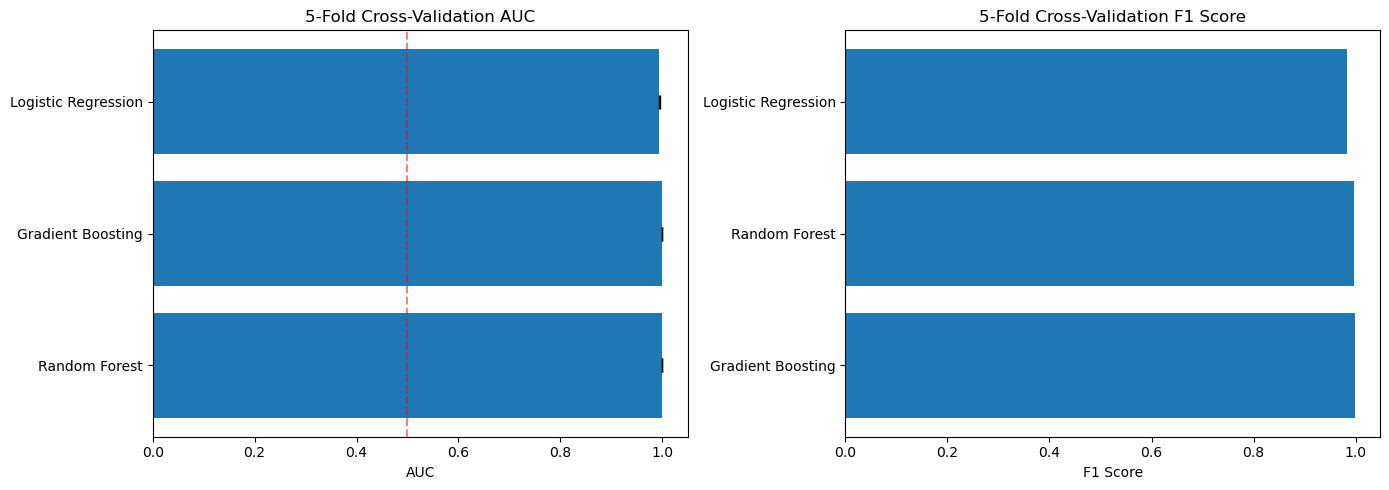


Best Model: Random Forest

Top 15 Feature Importances:
Feature  Importance
     BE    0.161949
     pH    0.141764
   APTT    0.127465
    Glu    0.127401
     Na    0.126464
    ALT    0.089585
    RDW    0.078361
    PO4    0.050188
     Ca    0.040750
   Urea    0.019853
    RBC    0.010089
     Hb    0.009994
    Lym    0.009924
    Lac    0.003140
    Alb    0.001095


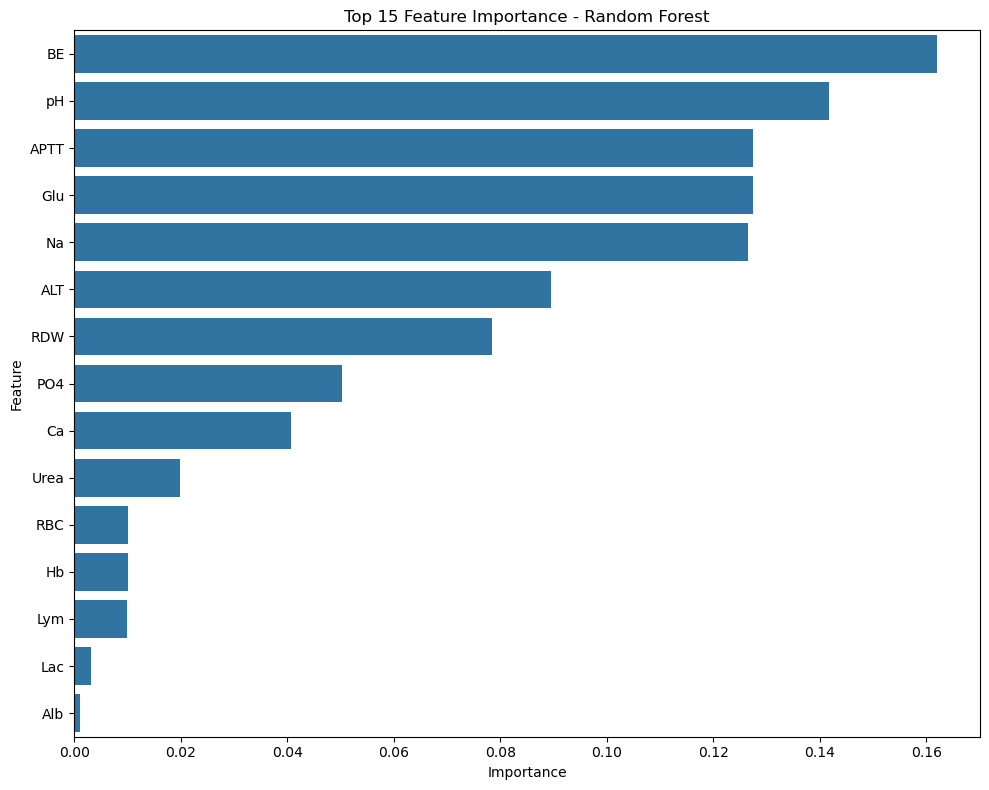

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('./model/data/SIC_data_processed.csv')

# Define features and target
target = 'SIC'
boolean_features = ['HTN', 'CKD', 'CA', 'DM', 'HLD', 'HF', 'IHD', 'COPD', 'Vent']
continuous_features = ['Age', 'Lym', 'Hb', 'RBC', 'RDW', 'K', 'Na', 'Ca', 
                       'Glu', 'Alb', 'Lac', 'pH', 'ALT', 'TBil', 'Crea', 'PO4', 
                       'Urea', 'BE', 'APTT'] # no PLT (label leakage)

# Combine all features
features = boolean_features + continuous_features

# Remove rows with missing target
df = df.dropna(subset=[target])

# Prepare feature matrix X and target y
X = df[features].copy()
y = df[target].astype(int)

# Handle missing values in continuous features (fill with median)
for col in continuous_features:
    if col in X.columns:
        X[col] = X[col].fillna(X[col].median())

# Convert boolean features to int
for col in boolean_features:
    if col in X.columns:
        X[col] = X[col].astype(int)

# Scale continuous features
scaler = StandardScaler()
for col in continuous_features:
    if col in X.columns:
        X[col] = scaler.fit_transform(X[[col]])

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*70)

results_summary = []

for name, model in models.items():
    print(f"\n{name}")
    print("-"*50)
    
    # Cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    
    # Get detailed metrics per fold
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    auc_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        
        accuracy_scores.append(accuracy_score(y_val, y_pred))
        precision_scores.append(precision_score(y_val, y_pred))
        recall_scores.append(recall_score(y_val, y_pred))
        f1_scores.append(f1_score(y_val, y_pred))
        auc_scores.append(roc_auc_score(y_val, y_pred_proba))
        
        print(f"  Fold {fold+1}: AUC = {auc_scores[-1]:.4f}, Acc = {accuracy_scores[-1]:.4f}, "
              f"Prec = {precision_scores[-1]:.4f}, Rec = {recall_scores[-1]:.4f}, F1 = {f1_scores[-1]:.4f}")
    
    print(f"\n  Summary:")
    print(f"    AUC: {np.mean(auc_scores):.4f} (+/- {np.std(auc_scores):.4f})")
    print(f"    Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
    print(f"    Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
    print(f"    Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
    print(f"    F1: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
    
    results_summary.append({
        'Model': name,
        'AUC_Mean': np.mean(auc_scores),
        'AUC_Std': np.std(auc_scores),
        'Accuracy_Mean': np.mean(accuracy_scores),
        'Precision_Mean': np.mean(precision_scores),
        'Recall_Mean': np.mean(recall_scores),
        'F1_Mean': np.mean(f1_scores)
    })

# Results summary
summary_df = pd.DataFrame(results_summary)
print("\n" + "="*70)
print("SUMMARY - 5-FOLD CROSS-VALIDATION")
print("="*70)
print(summary_df.to_string(index=False))

# Plot cross-validation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison
summary_df_sorted = summary_df.sort_values('AUC_Mean', ascending=False)
axes[0].barh(summary_df_sorted['Model'], summary_df_sorted['AUC_Mean'], 
             xerr=summary_df_sorted['AUC_Std'], capsize=5)
axes[0].set_xlabel('AUC')
axes[0].set_title('5-Fold Cross-Validation AUC')
axes[0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

# F1 comparison
summary_df_sorted = summary_df.sort_values('F1_Mean', ascending=False)
axes[1].barh(summary_df_sorted['Model'], summary_df_sorted['F1_Mean'])
axes[1].set_xlabel('F1 Score')
axes[1].set_title('5-Fold Cross-Validation F1 Score')

plt.tight_layout()
plt.savefig('./model/data/cv_results.png', dpi=150)
plt.show()

# Get feature importance from best model across all folds
best_model_name = summary_df.loc[summary_df['AUC_Mean'].idxmax(), 'Model']
print(f"\n{'='*70}")
print(f"Best Model: {best_model_name}")
print(f"{'='*70}")

# Train best model on full data for feature importance
best_model = models[best_model_name]
best_model.fit(X, y)

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 15 Feature Importances:")
    print(feature_importance.head(15).to_string(index=False))
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature')
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.savefig('./model/data/feature_importance.png', dpi=150)
    plt.show()